
# WMaxTwin Example II: Nason-type Wavelet Cross-Validation for the Doppler Signal

This notebook is a self-contained, GitHub-ready version of **Example II** in the WMaxTwin paper.  The example revisits Nason-style wavelet cross-validation for a single noisy Doppler signal and compares it with MaxTwin and WMaxTwin validation geometries.

The purpose is not merely to replace the classical even/odd split.  The purpose is to separate two distinct tasks:

1. **Split design**: choose training and validation locations in a geometry that makes validation representative but not redundant.
2. **Wavelet fitting under a mask**: once the split is not a regular dyadic subgrid, avoid applying an ordinary DWT to the retained observations as if they were a shorter regular signal.

The key construction is

$$
\hbox{WMaxTwin split geometry}
+
\hbox{masked wavelet regression}
+
\hbox{high-frequency ramp threshold family}.
$$

The notebook follows the supplied Python program closely.  It uses the Symmlet 4 periodized orthogonal wavelet transform, the Doppler signal with $n=1024$, $SNR=7$, and $\sigma=1$, and compares:

- noisy data,
- levelwise SURE thresholding,
- Nason even/odd cross-validation with a fixed threshold,
- location-only MaxTwin with a fixed threshold,
- WMaxTwin with a high-frequency ramp threshold,
- an oracle ramp benchmark.



## 1. Conceptual setup

Nason's original even/odd split is special because each retained half remains a regular subgrid.  This makes classical wavelet fitting and interpolation mathematically coherent.  A generic MaxTwin split of grid locations does not have this property.  The retained locations are usually irregular, so an ordinary DWT of the retained vector would not represent the wavelet transform of the original signal restricted to training observations.

Therefore, for MaxTwin and WMaxTwin masks we fit wavelet coefficients through a **masked penalized least-squares problem** on the original grid:

$$
\widehat d_\lambda
=
\arg\min_d
\left[
{1\over 2}\sum_{i=1}^n
m_i\{y_i-(W'd)_i\}^2
+
\sum_{j=3}^{9}\lambda_j\sum_k |d_{jk}|
\right].
$$

Here $m_i$ is the training indicator:

$$
m_i=
\begin{cases}
1, & \hbox{if } y_i \hbox{ is used for training},\\
0, & \hbox{if } y_i \hbox{ is held out for validation}.
\end{cases}
$$

The scaling coefficients at level $3$ are not penalized.  The optimization is solved by FISTA using only applications of $W$ and $W'$, so we do not need to explicitly form the full wavelet design matrix.


In [1]:

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Reproducibility and experiment defaults.
N = 1024
SNR = 7.0
SIGMA = 1.0
WAVELET = "sym4"
J0 = 3
NREP = 18
SEED = 2026
N_ITER = 30



## 2. Periodized orthogonal wavelet transform

The code below implements a compact, self-contained periodized orthogonal DWT.  The default wavelet is `sym4`, the 8-tap Symmlet.  The code also includes `db2`, the four-tap Daubechies D4 wavelet.

The transform returns the level-$J_0$ scaling coefficients and detail blocks $d_j$ for $j=J_0,\ldots,J-1$.  In the default experiment $n=1024=2^{10}$, so $J=10$ and the analyzed detail levels are

$$
j=3,4,\ldots,9.
$$


In [2]:

FILTERS = {
    "sym4": (
        np.array([
            -0.07576571478927333,
            -0.02963552764599851,
             0.49761866763201545,
             0.8037387518059161,
             0.29785779560527736,
            -0.09921954357684722,
            -0.012603967262037833,
             0.0322231006040427,
        ]),
        np.array([
            -0.0322231006040427,
            -0.012603967262037833,
             0.09921954357684722,
             0.29785779560527736,
            -0.8037387518059161,
             0.49761866763201545,
             0.02963552764599851,
            -0.07576571478927333,
        ]),
    ),
    "db2": (
        np.array([
            -0.12940952255126034,
             0.2241438680420134,
             0.8365163037378079,
             0.48296291314453416,
        ]),
        np.array([
            -0.48296291314453416,
             0.8365163037378079,
            -0.2241438680420134,
            -0.12940952255126034,
        ]),
    ),
}

_IDX_CACHE = {}


def get_idx(n, L):
    key = (n, L)
    if key not in _IDX_CACHE:
        m = n // 2
        _IDX_CACHE[key] = (2 * np.arange(m)[:, None] + np.arange(L)[None, :]) % n
    return _IDX_CACHE[key]


def dwt_step(x, h, g):
    idx = get_idx(len(x), len(h))
    X = x[idx]
    return X @ h, X @ g


def idwt_step(a, d, h, g):
    m = len(a)
    n = 2 * m
    idx = get_idx(n, len(h))
    vals = a[:, None] * h[None, :] + d[:, None] * g[None, :]
    x = np.zeros(n)
    np.add.at(x, idx.ravel(), vals.ravel())
    return x


def wavedec_periodic(x, j0=3, wavelet="sym4"):
    h, g = FILTERS[wavelet]
    n = len(x)
    J = int(np.log2(n))
    if 2**J != n:
        raise ValueError("n must be a power of two")
    if not (1 <= j0 < J):
        raise ValueError("j0 must satisfy 1 <= j0 < J")
    a = x.copy()
    details = {}
    for lev in range(J - 1, j0 - 1, -1):
        a, d = dwt_step(a, h, g)
        details[lev] = d
    return a, [details[j] for j in range(j0, J)]


def waverec_periodic(a, details, j0=3, wavelet="sym4"):
    h, g = FILTERS[wavelet]
    cur = a.copy()
    for d in details:
        cur = idwt_step(cur, d, h, g)
    return cur


def soft(x, lam):
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0.0)


def shrink_full(y, lams, j0=3, wavelet="sym4"):
    a, details = wavedec_periodic(y, j0, wavelet)
    details2 = [soft(d, lams[j0 + r]) for r, d in enumerate(details)]
    return waverec_periodic(a, details2, j0, wavelet)


In [3]:

# Reconstruction sanity check.
rng = np.random.default_rng(1)
x_test = rng.normal(size=N)
a_test, d_test = wavedec_periodic(x_test, J0, WAVELET)
x_rec = waverec_periodic(a_test, d_test, J0, WAVELET)
print(f"maximum reconstruction error: {np.max(np.abs(x_test - x_rec)):.3e}")


maximum reconstruction error: 4.115e-12



## 3. Doppler signal and threshold families

The Doppler signal is

$$
f_0(t)=\{t(1-t)\}^{1/2}\sin\left({2\pi\cdot 1.05\over t+0.05}\right),
\qquad 0<t<1.
$$

For prescribed $SNR=7$ and $\sigma=1$, the signal is centered and rescaled so that

$$
{\operatorname{var}\{f(t_i)\}\over \sigma^2}=SNR.
$$

The observed data are

$$
y_i=f(t_i)+\epsilon_i,\qquad \epsilon_i\stackrel{ind}{\sim}N(0,\sigma^2),
\qquad t_i={i-1/2\over n}.
$$

We use two threshold families:

1. A fixed threshold $\lambda_j=\lambda$ for Nason and location-only MaxTwin.
2. A WMaxTwin high-frequency ramp

$$
\lambda_j(s)=s\left({j-3\over 9-3}\right)^{3/2},
\qquad j=3,4,\ldots,9.
$$

The ramp is not WMaxTwin itself.  WMaxTwin defines the split geometry.  The ramp is an estimator-side threshold family aligned with the same high-frequency scales emphasized by the split.


In [4]:

def doppler_signal(n, snr=7.0, sigma=1.0):
    t = (np.arange(n) + 0.5) / n
    f = np.sqrt(t * (1.0 - t)) * np.sin(2.0 * np.pi * 1.05 / (t + 0.05))
    f = f - np.mean(f)
    f = f * np.sqrt(snr * sigma**2 / np.var(f))
    return t, f


def mse(a, b):
    return float(np.mean((a - b) ** 2))


def sure_threshold_detail(d, sigma=1.0):
    x = np.sort(np.abs(d))
    n = len(x)
    s2 = sigma**2
    csum = np.cumsum(x * x)
    k = np.arange(1, n + 1)
    risks = n * s2 + csum + (n - k) * x * x - 2.0 * s2 * k
    return float(x[int(np.argmin(risks))])


def level_sure_lams(y, j0=3, wavelet="sym4", sigma=1.0):
    J = int(np.log2(len(y)))
    _, details = wavedec_periodic(y, j0, wavelet)
    return {j: sure_threshold_detail(details[j - j0], sigma) for j in range(j0, J)}


def fixed_lams(lam, j0, J):
    return {j: float(lam) for j in range(j0, J)}


def ramp_lams(slope, j0, J, power=1.5):
    return {
        j: float(slope * ((j - j0) / (J - 1 - j0)) ** power)
        for j in range(j0, J)
    }


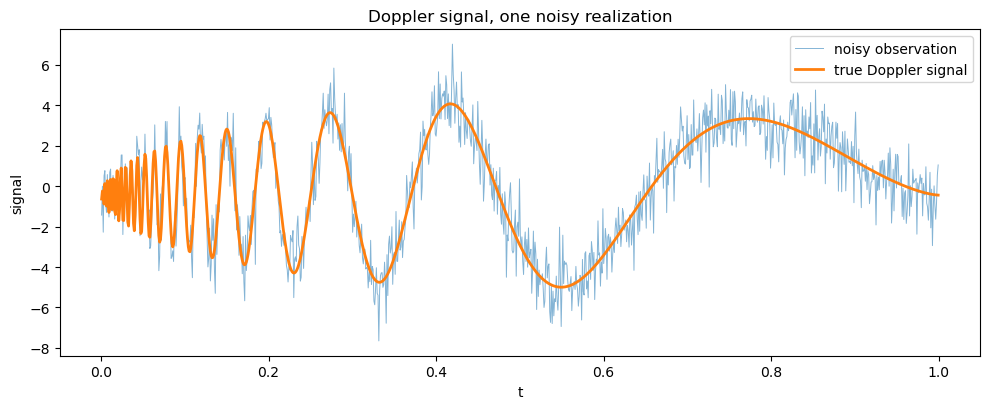

In [5]:

t, f = doppler_signal(N, SNR, SIGMA)
rng = np.random.default_rng(SEED)
y_demo = f + rng.normal(0.0, SIGMA, size=N)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(t, y_demo, linewidth=0.7, alpha=0.55, label="noisy observation")
ax.plot(t, f, linewidth=2.0, label="true Doppler signal")
ax.set_xlabel("t")
ax.set_ylabel("signal")
ax.set_title("Doppler signal, one noisy realization")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig01_doppler_signal.png", dpi=220)
plt.show()



## 4. Masked wavelet regression by FISTA

The fitting problem is convex.  The smooth part is the masked squared-error loss, and the nonsmooth part is the sum of absolute detail coefficients.  The implementation below uses FISTA:

- reconstruct from the current coefficient vector,
- compute residuals only on the training locations where $m_i=1$,
- transform the masked residuals back into wavelet coefficients,
- apply soft thresholding to detail coefficients,
- leave level-$3$ scaling coefficients unpenalized.

This is the appropriate way to combine a nonconforming MaxTwin mask with a wavelet estimator on the original grid.


In [6]:

def fit_masked_wavelet(y, mask, lams, j0=3, wavelet="sym4", n_iter=35):
    # Initialize from zero-filled masked data.
    a, details = wavedec_periodic(y * mask, j0, wavelet)
    za = a.copy()
    zd = [d.copy() for d in details]
    tk = 1.0

    for _ in range(n_iter):
        fz = waverec_periodic(za, zd, j0, wavelet)
        resid = mask * (fz - y)
        ga, gd = wavedec_periodic(resid, j0, wavelet)

        a_new = za - ga
        d_new = []
        for r, dz in enumerate(zd):
            j = j0 + r
            d_new.append(soft(dz - gd[r], lams[j]))

        t_new = (1.0 + np.sqrt(1.0 + 4.0 * tk * tk)) / 2.0
        za = a_new + ((tk - 1.0) / t_new) * (a_new - a)
        zd = [dn + ((tk - 1.0) / t_new) * (dn - do) for dn, do in zip(d_new, details)]
        a, details = a_new, d_new
        tk = t_new

    fit = waverec_periodic(a, details, j0, wavelet)
    return fit



## 5. Nason, MaxTwin, and WMaxTwin splits

The three splitting schemes are deliberately different.

### Nason even/odd split

Nason's split is grid-compatible:

$$
T=\{i:i\hbox{ even}\},\qquad R=\{i:i\hbox{ odd}\}.
$$

The geometry is parity.  It preserves a regular subgrid.

### Location-only MaxTwin

In one-dimensional location geometry, the natural MaxTwin pairing is adjacent twins.  Each adjacent pair contributes one training point and one validation point.  This gives local separation and balance, but does not use wavelet activity.

### WMaxTwin split

WMaxTwin augments location with local wavelet activity.  Let $q_i^{(j)}$ be the absolute contribution at location $t_i$ from detail level $j$ in a pilot reconstruction.  The feature vector is

$$
u_i=
\left(
{t_i-\bar t\over s_t},
\sqrt{\omega_3}q_i^{(3)},
\ldots,
\sqrt{\omega_9}q_i^{(9)}
\right),
$$

where the $q_i^{(j)}$ are standardized across locations.  The supplied Python program uses strong high-frequency emphasis: very small lower-level weights and much larger weights at $j=7,8,9$.  Pairing is performed greedily in this feature geometry, beginning with the most active high-frequency locations.  Pair orientation is then chosen to balance feature sums between the halves.

This is what WMaxTwin brings that ordinary MaxTwin does not: the split is not just local in $t$; it is local in a scale-aware geometry that sees where the Doppler signal is difficult to denoise.


In [7]:

def detail_contributions(y, j0=3, wavelet="sym4"):
    a, details = wavedec_periodic(y, j0, wavelet)
    zero_a = np.zeros_like(a)
    out = {}
    for r, d in enumerate(details):
        tmp = [np.zeros_like(dd) for dd in details]
        tmp[r] = d.copy()
        out[j0 + r] = waverec_periodic(zero_a, tmp, j0, wavelet)
    return out


def wmaxtwin_scale_weights(j0, J, mode="script"):
    # Relative weights for the WMaxTwin geometry.
    # mode='script' reproduces the supplied Python program exactly.
    # mode='paper_normalized' gives a normalized high-frequency ramp option.
    if mode == "script":
        weights = {}
        for j in range(j0, J):
            if j >= J - 3:
                rel = j - (J - 3)
                weights[j] = [1.0, 1.8, 2.6][rel]
            else:
                weights[j] = 0.10 * ((j - j0 + 1) / (J - j0)) ** 2
        return weights
    if mode == "paper_normalized":
        raw = {j: 0.05 + ((j - j0) / (J - 1 - j0)) ** 1.5 for j in range(j0, J)}
        total = sum(raw.values())
        return {j: raw[j] / total for j in range(j0, J)}
    raise ValueError("unknown weight mode")


def max_or_wmax_split(y, j0=3, wavelet="sym4", kind="wmax", seed=0, weight_mode="script"):
    n = len(y)
    t = (np.arange(n) + 0.5) / n

    if kind == "nason":
        return np.arange(0, n, 2), np.arange(1, n, 2)

    if kind == "max":
        # Location-only MaxTwin on a one-dimensional grid gives adjacent twins.
        pairs = [(i, i + 1) for i in range(0, n, 2)]
        train, val = [], []
        for p, (i, j) in enumerate(pairs):
            if p % 2 == 0:
                train.append(i); val.append(j)
            else:
                train.append(j); val.append(i)
        return np.array(train), np.array(val)

    # WMaxTwin: location plus high-frequency local wavelet activity.
    cont = detail_contributions(y, j0, wavelet)
    J = int(np.log2(n))
    feats = [(t - np.mean(t)) / np.std(t)]
    weights = wmaxtwin_scale_weights(j0, J, mode=weight_mode)

    for j in range(j0, J):
        wt = weights[j]
        q = np.abs(cont[j])
        q = (q - np.mean(q)) / (np.std(q) + 1e-12)
        feats.append(np.sqrt(wt) * q)
    X = np.column_stack(feats)

    activity = np.zeros(n)
    for j in range(max(j0, J - 3), J):
        activity += np.abs(cont[j])
    order = list(np.argsort(-activity))

    remaining = set(range(n))
    pairs = []
    for i in order:
        if i not in remaining:
            continue
        remaining.remove(i)
        if not remaining:
            break
        rem = np.fromiter(remaining, dtype=int)
        dist = np.sum((X[rem] - X[i]) ** 2, axis=1)
        jj = int(rem[int(np.argmin(dist))])
        remaining.remove(jj)
        pairs.append((i, jj))

    # Assign one twin to each side, greedily balancing the feature sums.
    bal = np.zeros(X.shape[1])
    train, val = [], []
    for i, j in pairs:
        diff = X[i] - X[j]
        if np.linalg.norm(bal + diff) <= np.linalg.norm(bal - diff):
            train.append(i); val.append(j); bal += diff
        else:
            train.append(j); val.append(i); bal -= diff
    return np.asarray(train), np.asarray(val)


In [8]:

# Display the actual WMaxTwin split weights used by the uploaded Python program.
J = int(np.log2(N))
script_weights = wmaxtwin_scale_weights(J0, J, mode="script")
weight_df = pd.DataFrame({
    "level_j": list(script_weights.keys()),
    "relative_weight_omega_j": list(script_weights.values()),
})
weight_df["normalized_for_display"] = weight_df["relative_weight_omega_j"] / weight_df["relative_weight_omega_j"].sum()
weight_df


,level_j,relative_weight_omega_j,normalized_for_display
0,3,0.002041,0.000374
1,4,0.008163,0.001495
2,5,0.018367,0.003363
3,6,0.032653,0.005979
4,7,1.000000,0.183109
5,8,1.800000,0.329596
6,9,2.600000,0.476084


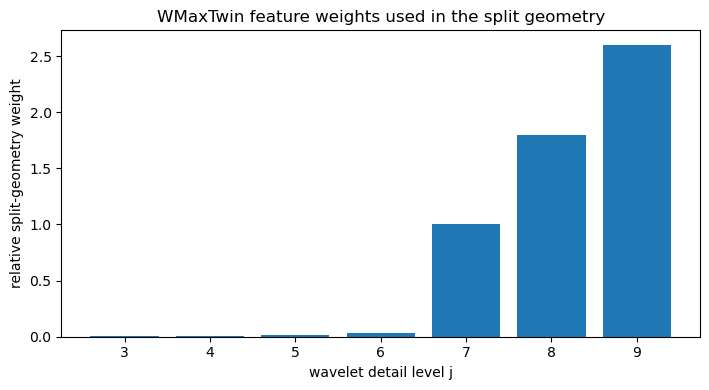

In [9]:

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.bar(weight_df["level_j"], weight_df["relative_weight_omega_j"])
ax.set_xlabel("wavelet detail level j")
ax.set_ylabel("relative split-geometry weight")
ax.set_title("WMaxTwin feature weights used in the split geometry")
ax.set_xticks(weight_df["level_j"])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig02_wmaxtwin_feature_weights.png", dpi=220)
plt.show()



## 6. Cross-validation selectors

For Nason and location-only MaxTwin we use a fixed threshold family:

$$
\lambda_j=\lambda,
\qquad j=3,\ldots,9.
$$

For WMaxTwin we use the high-frequency ramp family:

$$
\lambda_j(s)=s\left({j-3\over 9-3}\right)^{3/2}.
$$

For a split $(T,R)$, the symmetric validation score is

$$
CV(s)=
{1\over |R|}\sum_{i\in R}\{y_i-\widehat f_{T,s}(t_i)\}^2
+
{1\over |T|}\sum_{i\in T}\{y_i-\widehat f_{R,s}(t_i)\}^2.
$$

The WMaxTwin ramp uses a flat-minimum rule: among slopes whose CV score is within $1.5\%$ of the minimum, choose the largest slope.  This protects against underthresholding at the finest active levels.


In [10]:

def cv_select_fixed(y, train, val, j0=3, wavelet="sym4", n_iter=30):
    n = len(y)
    J = int(np.log2(n))
    mask_t = np.zeros(n); mask_t[train] = 1.0
    mask_v = np.zeros(n); mask_v[val] = 1.0
    rows = []
    for lam in np.linspace(0.2, 2.4, 12):
        lams = fixed_lams(lam, j0, J)
        pred_t = fit_masked_wavelet(y, mask_t, lams, j0, wavelet, n_iter)
        pred_v = fit_masked_wavelet(y, mask_v, lams, j0, wavelet, n_iter)
        score = np.mean((pred_t[val] - y[val]) ** 2) + np.mean((pred_v[train] - y[train]) ** 2)
        rows.append((float(score), float(lam)))
    rows = sorted(rows)
    return fixed_lams(rows[0][1], j0, J), rows[0], rows


def cv_select_ramp(y, train, val, j0=3, wavelet="sym4", n_iter=30, flat_tol=1.015):
    n = len(y)
    J = int(np.log2(n))
    mask_t = np.zeros(n); mask_t[train] = 1.0
    mask_v = np.zeros(n); mask_v[val] = 1.0
    rows = []
    for slope in np.linspace(0.6, 3.4, 15):
        lams = ramp_lams(slope, j0, J, power=1.5)
        pred_t = fit_masked_wavelet(y, mask_t, lams, j0, wavelet, n_iter)
        pred_v = fit_masked_wavelet(y, mask_v, lams, j0, wavelet, n_iter)
        score = np.mean((pred_t[val] - y[val]) ** 2) + np.mean((pred_v[train] - y[train]) ** 2)
        rows.append((float(score), float(slope)))
    rows = sorted(rows)
    min_score = rows[0][0]
    cand = [r for r in rows if r[0] <= flat_tol * min_score]
    chosen = max(cand, key=lambda z: z[1])
    return ramp_lams(chosen[1], j0, J, power=1.5), chosen, rows


def oracle_ramp(y, f, j0=3, wavelet="sym4"):
    J = int(np.log2(len(y)))
    best = (np.inf, None)
    for slope in np.linspace(0.4, 4.0, 37):
        lams = ramp_lams(slope, j0, J, power=1.5)
        err = mse(shrink_full(y, lams, j0, wavelet), f)
        if err < best[0]:
            best = (err, slope)
    return best



## 7. Monte Carlo experiment

The simulation matches the example configuration:

$$
n=1024,
\qquad SNR=7,
\qquad \sigma=1,
\qquad \hbox{wavelet} = \hbox{Symmlet 4},
\qquad j=3,\ldots,9.
$$

The paper reports a modest Monte Carlo run with 18 replications.  This is enough to illustrate the mechanism, but it should not be read as a final large-scale simulation study.


In [11]:

def run_simulation(n=1024, snr=7.0, sigma=1.0, wavelet="sym4", j0=3, nrep=18, seed=2026, n_iter=30, weight_mode="script"):
    J = int(np.log2(n))
    if 2**J != n:
        raise ValueError("n must be a power of two")

    t, f = doppler_signal(n, snr, sigma)
    rng = np.random.default_rng(seed)
    records = []
    saved = None
    start = time.time()

    for r in range(nrep):
        y = f + rng.normal(0.0, sigma, size=n)

        # Levelwise SURE benchmark.
        l_sure = level_sure_lams(y, j0, wavelet, sigma)
        f_sure = shrink_full(y, l_sure, j0, wavelet)

        # Nason-type even/odd split with fixed global threshold.
        tr_n, va_n = max_or_wmax_split(y, j0, wavelet, kind="nason", seed=r, weight_mode=weight_mode)
        l_n, ch_n, rows_n = cv_select_fixed(y, tr_n, va_n, j0, wavelet, n_iter)
        f_n = shrink_full(y, l_n, j0, wavelet)

        # Location-only MaxTwin with fixed global threshold.
        tr_m, va_m = max_or_wmax_split(y, j0, wavelet, kind="max", seed=r, weight_mode=weight_mode)
        l_m, ch_m, rows_m = cv_select_fixed(y, tr_m, va_m, j0, wavelet, n_iter)
        f_m = shrink_full(y, l_m, j0, wavelet)

        # WMaxTwin split and high-frequency ramp thresholds.
        tr_w, va_w = max_or_wmax_split(y, j0, wavelet, kind="wmax", seed=r, weight_mode=weight_mode)
        l_w, ch_w, rows_w = cv_select_ramp(y, tr_w, va_w, j0, wavelet, n_iter)
        f_w = shrink_full(y, l_w, j0, wavelet)

        err_oracle, slope_oracle = oracle_ramp(y, f, j0, wavelet)

        records.append({
            "rep": r + 1,
            "Noisy": mse(y, f),
            "LevelSure": mse(f_sure, f),
            "NasonEvenOddCV": mse(f_n, f),
            "MaxTwinFixedCV": mse(f_m, f),
            "WMaxTwinRampCV": mse(f_w, f),
            "OracleRamp": err_oracle,
            "selected_wmax_slope": ch_w[1],
            "oracle_slope": slope_oracle,
            "selected_fixed_nason": ch_n[1],
            "selected_fixed_maxtwin": ch_m[1],
        })

        if r == 0:
            saved = {
                "t": t, "f": f, "y": y,
                "f_sure": f_sure, "f_nason": f_n, "f_maxtwin": f_m, "f_wmax": f_w,
                "train_nason": tr_n, "val_nason": va_n,
                "train_maxtwin": tr_m, "val_maxtwin": va_m,
                "train_wmax": tr_w, "val_wmax": va_w,
                "l_wmax": l_w, "l_sure": l_sure, "l_nason": l_n, "l_maxtwin": l_m,
                "rows_wmax": rows_w,
                "chosen_wmax": ch_w,
                "j0": j0, "J": J,
                "wavelet": wavelet,
            }
        print(f"rep {r+1:2d}/{nrep} finished in {time.time()-start:6.2f}s", flush=True)

    return pd.DataFrame(records), saved


def summarize_results(df):
    methods = ["Noisy", "LevelSure", "NasonEvenOddCV", "MaxTwinFixedCV", "WMaxTwinRampCV", "OracleRamp"]
    labels = {
        "Noisy": "Noisy data",
        "LevelSure": "LevelSure",
        "NasonEvenOddCV": "Nason even/odd CV",
        "MaxTwinFixedCV": "MaxTwin fixed-threshold CV",
        "WMaxTwinRampCV": "WMaxTwin ramp CV",
        "OracleRamp": "Oracle ramp",
    }
    rows = []
    for m in methods:
        rows.append({
            "Method": labels[m],
            "AMSE": df[m].mean(),
            "SD": df[m].std(ddof=1),
            "SE": df[m].std(ddof=1) / np.sqrt(len(df)),
        })
    return pd.DataFrame(rows)


In [12]:

df, saved = run_simulation(
    n=N,
    snr=SNR,
    sigma=SIGMA,
    wavelet=WAVELET,
    j0=J0,
    nrep=NREP,
    seed=SEED,
    n_iter=N_ITER,
    weight_mode="script",
)
summary = summarize_results(df)

# Save numerical outputs for reproducibility.
df.to_csv(OUTPUT_DIR / "doppler_replicates.csv", index=False)
summary.to_csv(OUTPUT_DIR / "doppler_amse_summary.csv", index=False)
summary


rep  1/18 finished in   0.36s
rep  2/18 finished in   0.75s
rep  3/18 finished in   1.18s
rep  4/18 finished in   1.60s
rep  5/18 finished in   2.04s
rep  6/18 finished in   2.38s
rep  7/18 finished in   2.73s
rep  8/18 finished in   3.09s
rep  9/18 finished in   3.49s
rep 10/18 finished in   3.96s
rep 11/18 finished in   4.58s
rep 12/18 finished in   5.01s
rep 13/18 finished in   5.37s
rep 14/18 finished in   5.73s
rep 15/18 finished in   6.11s
rep 16/18 finished in   6.48s
rep 17/18 finished in   6.83s
rep 18/18 finished in   7.26s


,Method,AMSE,SD,SE
0,Noisy data,1.005513,0.036495,0.008602
1,LevelSure,0.142233,0.016748,0.003948
2,Nason even/odd CV,0.193908,0.020238,0.004770
3,MaxTwin fixed-threshold CV,0.211798,0.021865,0.005154
4,WMaxTwin ramp CV,0.134891,0.013455,0.003171
5,Oracle ramp,0.130976,0.013286,0.003132


rep  3/18 finished in   1.42s


rep  4/18 finished in   2.00s


rep  5/18 finished in   2.53s


...

rep 15/18 finished in   7.64s


rep 16/18 finished in   8.11s


rep 17/18 finished in   8.56s


rep 18/18 finished in   9.04s


,Method,AMSE,SD,SE
0,Noisy data,1.005513,0.036495,0.008602
1,LevelSure,0.142233,0.016748,0.003948
2,Nason even/odd CV,0.193908,0.020238,0.004770
3,MaxTwin fixed-threshold CV,0.211798,0.021865,0.005154
4,WMaxTwin ramp CV,0.134891,0.013455,0.003171
5,Oracle ramp,0.130976,0.013286,0.003132



## 8. Split diagnostics

The next figure compares the three masks for the first replication.  The Nason mask is perfectly periodic.  The location-only MaxTwin mask is adjacent-pair based.  The WMaxTwin mask is nonconforming because it is paired in a geometry that includes location and wavelet activity.

This nonconformity is precisely why the masked wavelet fit is needed.


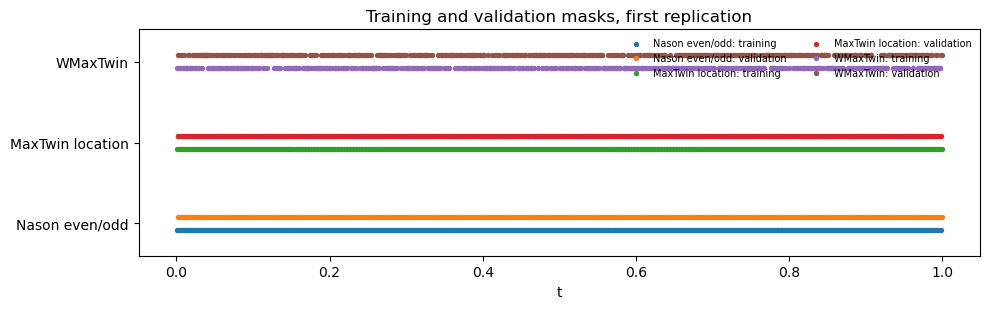

In [13]:

def plot_split_comparison(saved):
    t = saved["t"]
    fig, ax = plt.subplots(figsize=(10, 3.2))

    rows = [
        ("Nason even/odd", saved["train_nason"], saved["val_nason"], 0),
        ("MaxTwin location", saved["train_maxtwin"], saved["val_maxtwin"], 1),
        ("WMaxTwin", saved["train_wmax"], saved["val_wmax"], 2),
    ]

    for label, tr, va, base in rows:
        ax.scatter(t[tr], np.full_like(tr, base - 0.08, dtype=float), s=8, label=f"{label}: training")
        ax.scatter(t[va], np.full_like(va, base + 0.08, dtype=float), s=8, label=f"{label}: validation")

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels([r[0] for r in rows])
    ax.set_xlabel("t")
    ax.set_title("Training and validation masks, first replication")
    ax.set_ylim(-0.4, 2.4)
    ax.legend(loc="upper right", frameon=False, fontsize=7, ncol=2)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig03_split_comparison.png", dpi=220)
    plt.show()

plot_split_comparison(saved)



## 9. One-run reconstructions

This plot shows the first Monte Carlo replication.  The WMaxTwin ramp-CV reconstruction is not simply a result of changing the split.  It combines:

- a multiscale split geometry,
- a masked wavelet fit valid under the nonconforming mask,
- a ramp threshold family aimed at the difficult fine scales.


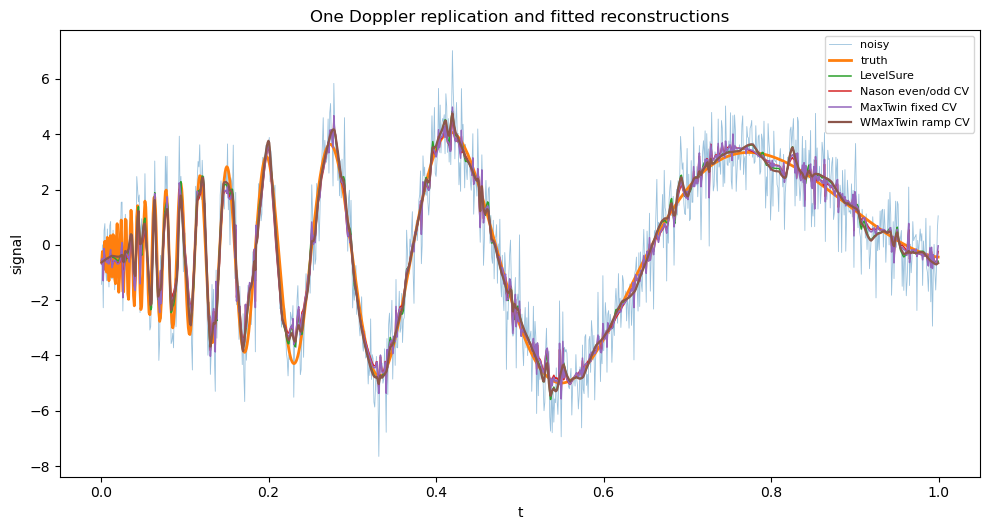

In [14]:

def plot_one_run(saved):
    t = saved["t"]
    fig, ax = plt.subplots(figsize=(10, 5.4))
    ax.plot(t, saved["y"], linewidth=0.6, alpha=0.45, label="noisy")
    ax.plot(t, saved["f"], linewidth=2.0, label="truth")
    ax.plot(t, saved["f_sure"], linewidth=1.1, label="LevelSure")
    ax.plot(t, saved["f_nason"], linewidth=1.1, label="Nason even/odd CV")
    ax.plot(t, saved["f_maxtwin"], linewidth=1.1, label="MaxTwin fixed CV")
    ax.plot(t, saved["f_wmax"], linewidth=1.6, label="WMaxTwin ramp CV")
    ax.set_xlabel("t")
    ax.set_ylabel("signal")
    ax.set_title("One Doppler replication and fitted reconstructions")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig04_one_run_reconstructions.png", dpi=220)
    plt.show()

plot_one_run(saved)



## 10. Threshold diagnostics

The WMaxTwin selected thresholds follow the ramp shape.  By construction, $\lambda_3=0$ and the strongest threshold is at $j=9$.  Levelwise SURE is included as a classical benchmark.


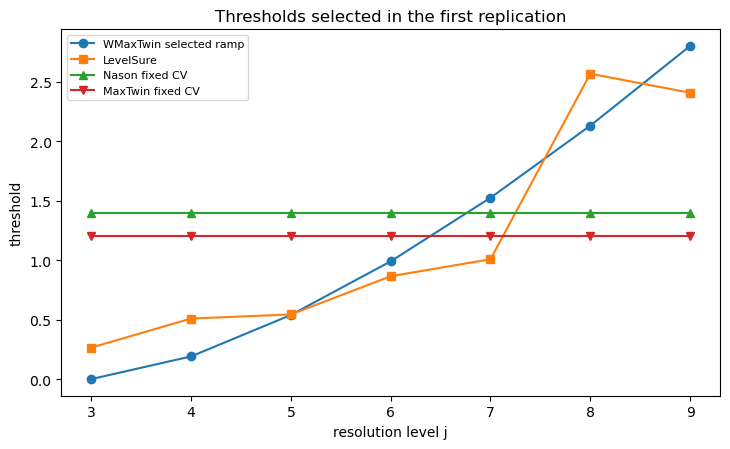

In [15]:

def plot_thresholds(saved):
    j0, J = saved["j0"], saved["J"]
    js = np.arange(j0, J)
    lam_w = np.array([saved["l_wmax"][int(j)] for j in js])
    lam_s = np.array([saved["l_sure"][int(j)] for j in js])
    lam_n = np.array([saved["l_nason"][int(j)] for j in js])
    lam_m = np.array([saved["l_maxtwin"][int(j)] for j in js])

    fig, ax = plt.subplots(figsize=(7.4, 4.6))
    ax.plot(js, lam_w, marker="o", label="WMaxTwin selected ramp")
    ax.plot(js, lam_s, marker="s", label="LevelSure")
    ax.plot(js, lam_n, marker="^", label="Nason fixed CV")
    ax.plot(js, lam_m, marker="v", label="MaxTwin fixed CV")
    ax.set_xlabel("resolution level j")
    ax.set_ylabel("threshold")
    ax.set_title("Thresholds selected in the first replication")
    ax.set_xticks(js)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig05_thresholds.png", dpi=220)
    plt.show()

plot_thresholds(saved)



## 11. WMaxTwin ramp CV curve

The flat-minimum rule selects the largest slope within $1.5\%$ of the minimum score.  This is a conservative rule against underthresholding at the active high-frequency levels.


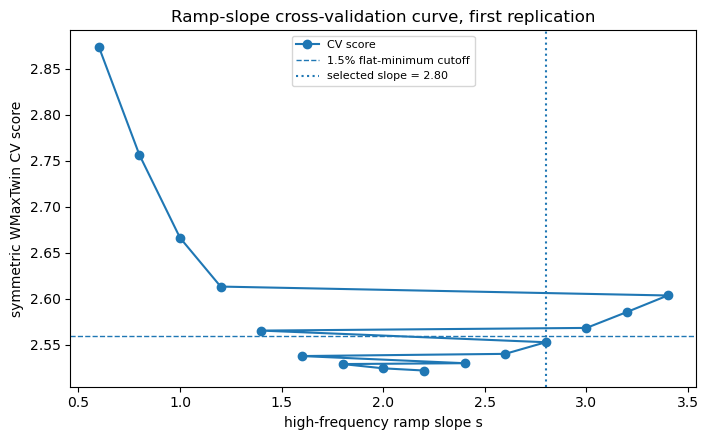

In [16]:

def plot_cv_curve(saved):
    rows = np.asarray(saved["rows_wmax"])
    chosen_score, chosen_slope = saved["chosen_wmax"]
    min_score = rows[:, 0].min()
    cutoff = 1.015 * min_score

    fig, ax = plt.subplots(figsize=(7.2, 4.5))
    ax.plot(rows[:, 1], rows[:, 0], marker="o", label="CV score")
    ax.axhline(cutoff, linestyle="--", linewidth=1.0, label="1.5% flat-minimum cutoff")
    ax.axvline(chosen_slope, linestyle=":", linewidth=1.5, label=f"selected slope = {chosen_slope:.2f}")
    ax.set_xlabel("high-frequency ramp slope s")
    ax.set_ylabel("symmetric WMaxTwin CV score")
    ax.set_title("Ramp-slope cross-validation curve, first replication")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig06_cv_curve.png", dpi=220)
    plt.show()

plot_cv_curve(saved)



## 12. Monte Carlo AMSE comparison

The AMSE is the average mean squared error against the known Doppler truth:

$$
AMSE = {1\over n}\sum_{i=1}^n \{\widehat f(t_i)-f(t_i)\}^2.
$$

The important diagnostic is that the fixed-threshold MaxTwin version does not improve on the Nason benchmark.  Merely changing the split to a MaxTwin geometry is not sufficient.  The successful method is the full WMaxTwin construction: multiscale split, masked fit, and high-frequency ramp.


In [17]:

# Display the summary table with rounded values.
summary_rounded = summary.copy()
for col in ["AMSE", "SD", "SE"]:
    summary_rounded[col] = summary_rounded[col].map(lambda x: f"{x:.4f}")
summary_rounded


,Method,AMSE,SD,SE
0,Noisy data,1.0055,0.0365,0.0086
1,LevelSure,0.1422,0.0167,0.0039
2,Nason even/odd CV,0.1939,0.0202,0.0048
3,MaxTwin fixed-threshold CV,0.2118,0.0219,0.0052
4,WMaxTwin ramp CV,0.1349,0.0135,0.0032
5,Oracle ramp,0.1310,0.0133,0.0031


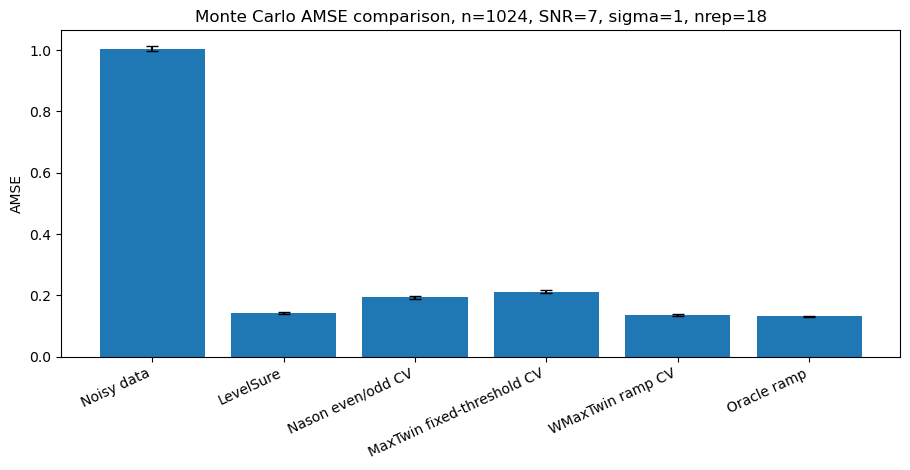

In [18]:

def plot_amse(summary):
    fig, ax = plt.subplots(figsize=(9.2, 4.8))
    ax.bar(summary["Method"], summary["AMSE"], yerr=summary["SE"], capsize=4)
    ax.set_ylabel("AMSE")
    ax.set_title(f"Monte Carlo AMSE comparison, n={N}, SNR={SNR:g}, sigma={SIGMA:g}, nrep={NREP}")
    ax.set_xticks(np.arange(len(summary["Method"])))
    ax.set_xticklabels(summary["Method"], rotation=25, ha="right")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig07_amse_bar.png", dpi=220)
    plt.show()

plot_amse(summary)



## 13. Slope diagnostics

The oracle ramp is not a method: it uses the known true signal and is included only as an unattainable benchmark within the same ramp family.  The next plot compares the selected WMaxTwin slope to the oracle slope across the 18 replications.


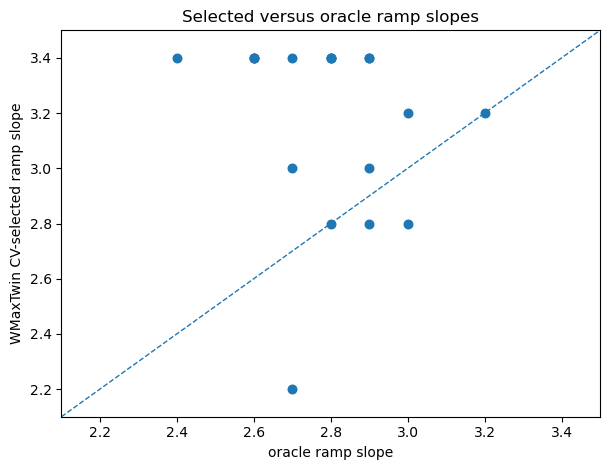

In [19]:

def plot_slope_diagnostics(df):
    fig, ax = plt.subplots(figsize=(6.2, 4.8))
    ax.scatter(df["oracle_slope"], df["selected_wmax_slope"], s=38)
    lo = min(df["oracle_slope"].min(), df["selected_wmax_slope"].min()) - 0.1
    hi = max(df["oracle_slope"].max(), df["selected_wmax_slope"].max()) + 0.1
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.0)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("oracle ramp slope")
    ax.set_ylabel("WMaxTwin CV-selected ramp slope")
    ax.set_title("Selected versus oracle ramp slopes")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig08_slope_diagnostics.png", dpi=220)
    plt.show()

plot_slope_diagnostics(df)



## 14. Interpretation

The example is deliberately narrow but useful.

First, the Nason even/odd split is not being dismissed.  It is the canonical grid-compatible construction for wavelet cross-validation on one signal.  Its mathematical strength is that the retained observations remain on a regular subgrid.

Second, location-only MaxTwin is not enough here.  In this simulation it uses a MaxTwin-type location split but retains a fixed threshold family, and it does not improve on the Nason benchmark.

Third, WMaxTwin contributes a different validation geometry.  The split sees high-frequency local activity through $q_i^{(j)}$ and emphasizes levels $7,8,9$.  Once a nonconforming WMaxTwin mask is used, the wavelet estimator must be written as masked wavelet regression on the original grid.  The successful method is the combined construction:

$$
\hbox{multiscale split geometry}
+
\hbox{valid masked wavelet fit}
+
\hbox{high-frequency ramp threshold family}.
$$

Thus WMaxTwin is not simply “levelwise thresholds.”  The thresholds are part of the estimator and tuning family.  WMaxTwin is the scale-aware split-design component that makes the validation problem sensitive to the locations and resolutions where the Doppler curve is difficult.



## 15. Files generated by this notebook

The notebook writes numerical and graphical outputs to the `outputs/` directory:

- `doppler_replicates.csv`: replication-level MSE values and selected slopes,
- `doppler_amse_summary.csv`: AMSE, SD, and Monte Carlo SE table,
- `fig01_doppler_signal.png`,
- `fig02_wmaxtwin_feature_weights.png`,
- `fig03_split_comparison.png`,
- `fig04_one_run_reconstructions.png`,
- `fig05_thresholds.png`,
- `fig06_cv_curve.png`,
- `fig07_amse_bar.png`,
- `fig08_slope_diagnostics.png`.

For a larger run, increase `NREP`.  For other grid sizes, use powers of two such as `N=512`, `N=2048`, or `N=4096`.
